In [94]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import i24_motion_macro
import matplotlib.pyplot as plt
import numpy
import gc
import optuna

In [95]:
def fft_four_convs(Dp, Mp, k_cong, k_free, eps=1e-12, use_ortho=True):
    """
    Compute via FFT:
        sum_cong = conv2d(Dp, k_cong)
        sum_free = conv2d(Dp, k_free)
        N_cong   = conv2d(Mp, k_cong)
        N_free   = conv2d(Mp, k_free)
    Inputs:
      Dp, Mp:   (B, C, H, W)
      k_cong,:  (F, C, Kh, Kw)
      k_free:   (F, C, Kh, Kw)
    Returns:
      sum_cong, N_cong, sum_free, N_free each of shape (B, F, H-Kh+1, W-Kw+1)
    """
    # ——— sanitize inputs ———
    Dp = torch.nan_to_num(Dp, nan=0.0, posinf=0.0, neginf=0.0)
    Mp = torch.nan_to_num(Mp, nan=0.0, posinf=0.0, neginf=0.0)

    B, C, H, W        = Dp.shape
    F, _, Kh, Kw      = k_cong.shape
    Fh, Fw            = H + Kh - 1, W + Kw - 1
    device, dtype     = Dp.device, Dp.dtype

    # ——— pad inputs ———
    Dp_pad = torch.zeros(B, C, Fh, Fw, device=device, dtype=dtype)
    Mp_pad = torch.zeros(B, C, Fh, Fw, device=device, dtype=dtype)
    Dp_pad[..., :H, :W] = Dp
    Mp_pad[..., :H, :W] = Mp

    # ——— pad kernels ———
    k1_pad = torch.zeros(F, C, Fh, Fw, device=device, dtype=dtype)
    k2_pad = torch.zeros(F, C, Fh, Fw, device=device, dtype=dtype)
    k1_pad[..., :Kh, :Kw] = k_cong
    k2_pad[..., :Kh, :Kw] = k_free

    # choose normalization
    norm = "ortho" if use_ortho else None

    # ——— FFT both inputs and kernels ———
    Df  = torch.fft.rfftn(Dp_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    Mf  = torch.fft.rfftn(Mp_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    Kf1 = torch.fft.rfftn(k1_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    Kf2 = torch.fft.rfftn(k2_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)

    # ——— pointwise multiply in freq domain ———
    Y1 = Df * Kf1    # for sum_cong
    Y2 = Df * Kf2    # for sum_free
    Z1 = Mf * Kf1    # for N_cong
    Z2 = Mf * Kf2    # for N_free

    # ——— inverse FFT back to real ———
    y1 = torch.fft.irfftn(Y1, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    y2 = torch.fft.irfftn(Y2, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    z1 = torch.fft.irfftn(Z1, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    z2 = torch.fft.irfftn(Z2, dim=(-2, -1), s=(Fh, Fw), norm=norm)

    # ——— crop “valid” region ———
    oh, ow = H - Kh + 1, W - Kw + 1
    sum_cong = y1[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]
    sum_free = y2[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]
    N_cong   = z1[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]
    N_free   = z2[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]

    # ——— optional epsilon to counts to avoid zero division downstream ———
    N_cong = N_cong + eps
    N_free = N_free + eps

    return sum_cong, N_cong, sum_free, N_free

class AdaptiveSmoothing(nn.Module):
    def __init__(self,
                 kernel_time_window: float,
                 kernel_space_window: float,
                 dx: float,
                 dt: float,
                 init_delta: float = 0.02, # mile
                 init_tau: float = 4.0, # seconds
                 init_c_cong: float = 12.0,
                 init_c_free: float = -45.0,
                 init_v_thr: float = 40.0,
                 init_v_delta: float = 10.0,
                 high_is_congestion=False):
        super().__init__()
        self.size_t = int(kernel_time_window / dt)
        self.size_x = int(kernel_space_window / dx)
        self.dt = dt
        self.dx = dx

        t_offs = torch.arange(-self.size_t, self.size_t + 1) * dt
        # print(t_offs)
        x_offs = torch.arange(-self.size_x, self.size_x + 1) * dx
        # print(x_offs)
        #X, T = torch.meshgrid(x_offs, t_offs, indexing='ij')
        T, X = torch.meshgrid(t_offs, x_offs, indexing='ij')
        self.register_buffer('T_offsets', T.float())
        self.register_buffer('X_offsets', X.float())

        self.delta   = nn.Parameter(torch.tensor(init_delta))
        self.tau     = nn.Parameter(torch.tensor(init_tau))
        self.c_cong  = nn.Parameter(torch.tensor(init_c_cong))
        self.c_free  = nn.Parameter(torch.tensor(init_c_free))
        self.v_thr   = nn.Parameter(torch.tensor(init_v_thr))
        self.v_delta = nn.Parameter(torch.tensor(init_v_delta))
        self.high_is_congestion = high_is_congestion

    def forward(self, raw_data: torch.Tensor):
        # Ensure input is 4D: (B, C, T, X)
        
        if raw_data.ndim == 2:
            raw_data = raw_data.unsqueeze(0).unsqueeze(0)
        elif raw_data.ndim == 3:
            raw_data = raw_data.unsqueeze(1)

        mask = (~raw_data.isnan()).float()
        data = torch.nan_to_num(raw_data, nan=0.0)

        c_cong_s = self.c_cong #/ 3600.0 Already at meters per second
        c_free_s = self.c_free #/ 3600.0 Already at meters per second
        t_cong = self.T_offsets - self.X_offsets / c_cong_s
        t_free = self.T_offsets - self.X_offsets / c_free_s

        k_cong = torch.exp(-(t_cong.abs() / self.tau + self.X_offsets.abs() / self.delta))
        # size of k_cong
        k_free = torch.exp(-(t_free.abs() / self.tau + self.X_offsets.abs() / self.delta))

        k_cong = k_cong.unsqueeze(0).unsqueeze(0)  # (1,1,Kt,Kx)
        k_free = k_free.unsqueeze(0).unsqueeze(0)

        #pad = (self.size_t, self.size_t, self.size_x, self.size_x) # to deal with the edge effects
        pad = (self.size_x, self.size_x, self.size_t, self.size_t) # to deal with the edge effects
        Dp = F.pad(data, pad, value=0.0)
        Mp = F.pad(mask, pad, value=0.0)

        sum_cong = F.conv2d(Dp, k_cong)
        N_cong   = F.conv2d(Mp, k_cong)
        sum_free = F.conv2d(Dp, k_free)
        N_free   = F.conv2d(Mp, k_free)
        # use FFT to compute the convolutions
        #sum_cong, N_cong, sum_free, N_free = fft_four_convs(Dp, Mp, k_cong, k_free)

        v_cong = sum_cong / N_cong
        v_free = sum_free / N_free
        
        if (self.high_is_congestion):
            v_max = torch.max(v_cong, v_free)
            w = 0.5 * (1 + torch.tanh((v_max - self.v_thr) / self.v_delta))
            v = w * v_cong + (1 - w) * v_free
        else:
            v_min = torch.min(v_cong, v_free)
            w = 0.5 * (1 + torch.tanh((self.v_thr - v_min) / self.v_delta))
            v = w * v_cong + (1 - w) * v_free

        valid_cong = (N_cong > 0).float()
        valid_free = (N_free > 0).float()
        # if no cong data → use free; if no free data → use cong
        v = valid_cong*valid_free*v + (1-valid_cong)*v_free + (1-valid_free)*v_cong
        # check if there's nan if so print
        if torch.isnan(v).any():
            print("Warning! NaN detected in output")
            print(N_cong)
        # print size of v
        return v.squeeze(1)


In [96]:
i24macro = i24_motion_macro.I24MotionMacro(i24_motion_macro.i24_motion_data.I24MotionData(2, 1669812350, 1669812350+3600, 0, 1600), 2, "road_2", longitudinal_cell_size=100.0, time_delta=1.0)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [97]:
raw_macro = i24macro.loadRawMacroData()

In [98]:
queries = i24macro.computeEdieBoxQueries()

In [99]:
queries.keys()

dict_keys(['timestamp_min', 'timestamp_max', 's_min', 's_max'])

In [100]:
density_result, velocity_result, flow_result = raw_macro[-1]["density"], raw_macro[-1]["velocity"], raw_macro[-1]["flow"]
outage_mask = []
for i, entry in enumerate(zip(queries['s_min'], queries['s_max'])):
    s_min, s_max = entry[0], entry[1]
    outage_mask.append(False)
    for outage in [[400.0, 600.0], [1000.0, 1100.0]]:
        if (s_min >= outage[0]) and (s_min <= outage[1]):
            outage_mask[-1] = True
outage_mask = numpy.isnan(velocity_result) | outage_mask
velocity_result_mask = ~(outage_mask)
print(velocity_result_mask)
density_result_stat = density_result[velocity_result_mask]
velocity_result_stat = velocity_result[velocity_result_mask]
flow_result_stat = flow_result[velocity_result_mask]
print(density_result_stat.min(), density_result_stat.mean(), density_result_stat.max(), density_result_stat.std())
print(velocity_result_stat.min(), velocity_result_stat.mean(), velocity_result_stat.max(), velocity_result_stat.std())
print(flow_result_stat.min(), flow_result_stat.mean(), flow_result_stat.max(), flow_result_stat.std())
print(density_result.shape, velocity_result.shape, flow_result.shape)

[ True  True  True ...  True  True  True]
0.0 0.041187335 0.14 0.019625375
0.0 32.72059 45.0 14.391439
0.0 1.1534907 4.05 0.53481615
(57600,) (57600,) (57600,)


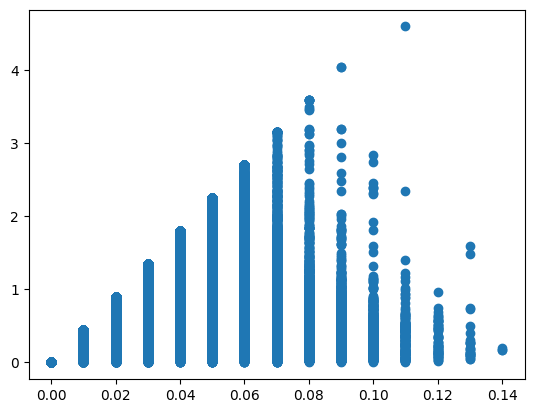

In [101]:
plt.scatter(density_result, flow_result)

In [102]:
p = numpy.polyfit(density_result_stat, flow_result_stat, deg=2)

In [103]:
p

array([-4.86251919e+02,  4.91079796e+01,  1.43022491e-01])

In [104]:
density_range = numpy.arange(0, 0.12, 0.001)
def polyfunction(p, d):
    return (p[0] * (d ** 2.0)) + (p[1] * d) + p[2]

estimated_flow = numpy.array([polyfunction(p, d) for d in density_range])

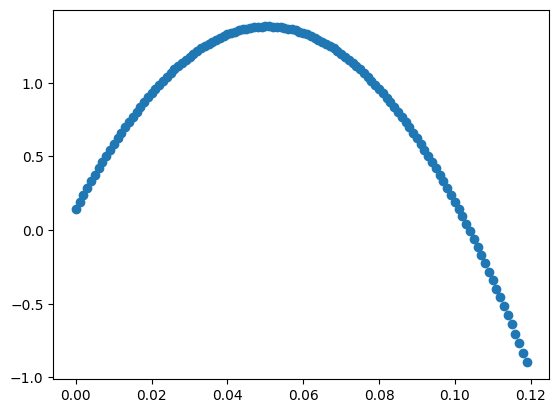

In [105]:
plt.scatter(density_range, estimated_flow)

In [106]:
p = numpy.polyfit(velocity_result_stat, flow_result_stat, deg=2)
velocity_range = numpy.arange(0, 102.0, 1.0)
def polyfunction(p, d):
    return  (p[0] * (d ** 2.0)) + (p[1] * d) + p[2]

estimated_flow = numpy.array([polyfunction(p, d) for d in velocity_range])

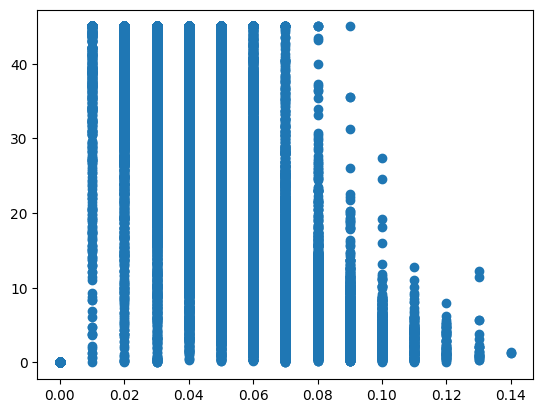

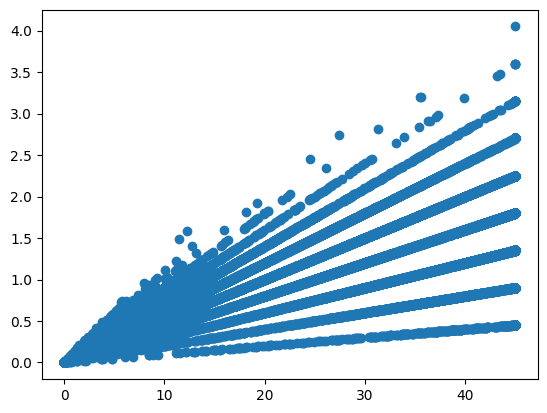

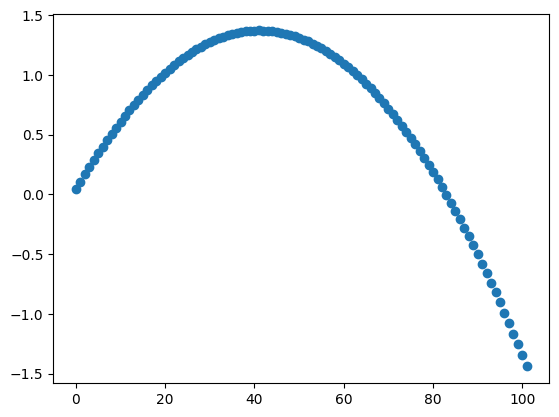

In [107]:
plt.scatter(density_result_stat, velocity_result_stat)
plt.show()
plt.scatter(velocity_result_stat, flow_result_stat)
plt.show()
plt.scatter(velocity_range, estimated_flow)
plt.show()

[-504.16833789   53.48593803]


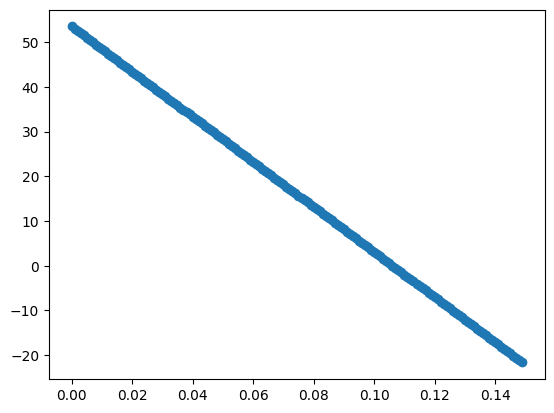

In [108]:
p = numpy.polyfit(density_result_stat, velocity_result_stat, deg=1)
print(p)
density_range = numpy.arange(0, 0.15, 0.001)
def polyfunction(p, d):
    return (p[0] * d) + p[1]

estimated_velocity = numpy.array([polyfunction(p, d) for d in density_range])
plt.scatter(density_range, estimated_velocity)
plt.show()


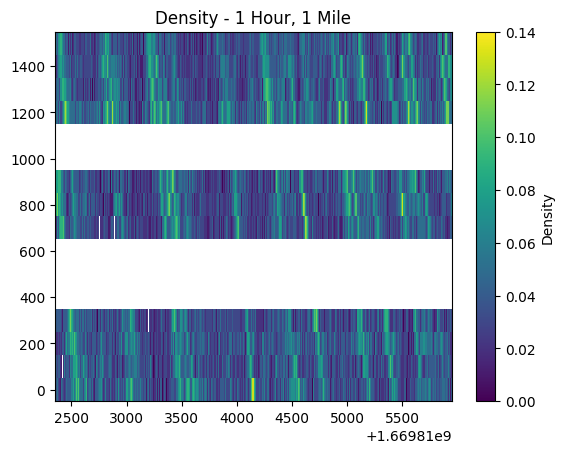

In [109]:
timestamp_min_display = numpy.array(queries["timestamp_min"]).reshape((3600, 16)).T
s_min_display = numpy.array(queries["s_min"]).reshape((3600, 16)).T
density_result_display = density_result.copy()
density_result_display[outage_mask] = numpy.nan
density_result_display = density_result_display.reshape((3600, 16)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

In [110]:
print(min(queries["s_min"]), max(queries["s_max"]))

0.0 1600.0


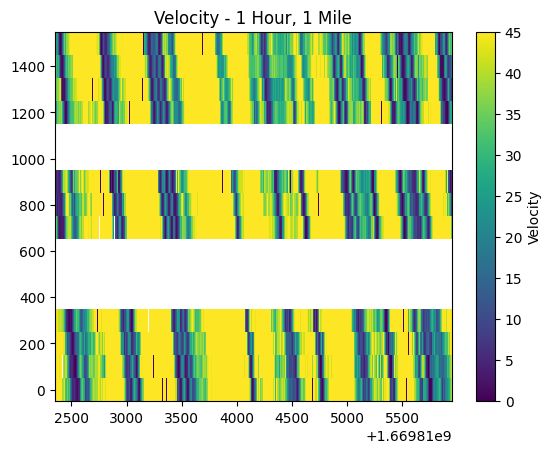

In [111]:
timestamp_min_display = numpy.array(queries["timestamp_min"]).reshape((3600, 16)).T
s_min_display = numpy.array(queries["s_min"]).reshape((3600, 16)).T
velocity_result_display = velocity_result.copy()
velocity_result_display[outage_mask] = numpy.nan
velocity_result_display = velocity_result_display.reshape((3600, 16)).T
plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto')
plt.title('Velocity - 1 Hour, 1 Mile')
plt.colorbar(label='Velocity')
plt.show()

In [112]:
#del velocity_result_asm_output
#del density_result_asm_output
#gc.collect()
velocity_result_marked_outages = velocity_result.copy()
velocity_result_marked_outages[outage_mask] = numpy.nan
velocity_result_asm_input = velocity_result_marked_outages.reshape((1, 1, 3600, 16))
velocity_result_asm_input = torch.from_numpy(velocity_result_asm_input).to("cuda")
"""init_delta: float = 32.0, # meters
init_tau: float = 4.0, # seconds
init_c_cong: float = -5.36, # Meters per second going backwards
init_c_free: float = 20.00 # Meters per second going forwards
init_v_thr: float = 17.00, # Meters per second
init_v_delta: float = 4.5 # Meters per second"""
"""
{'init_c_cong': -4.386450786436988,
 'init_c_free': 41.09152765794657,
 'init_delta': 105.62640175480215,
 'init_tau': 0.1052379737326149,
 'v_thr': 0.0609944197208978,
 'v_delta': 0.03731597995330584}
 """

"""
{'init_c_cong': -4.435442333413168,
 'init_c_free': 31.835619183232694,
 'v_thr': 0.062871015625177,
 'v_delta': 0.005002742521751672}
"""


asm = AdaptiveSmoothing(3600.0, 1600.0, dx=100.0, dt=1.0, init_delta=15.0, init_tau=1.0, init_c_cong=-7.7, init_c_free=50.0, init_v_thr=21.22, init_v_delta=0.5).to("cuda")
#asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=10.197239034761685, init_tau=0.6226188217629887, init_c_cong=-5.36, init_c_free=45.0, init_v_thr=10.55926695516419, init_v_delta=1.1422346804487675).to("cuda")
#asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=7.347636200013352, init_tau=0.10218764308860165, init_c_cong=-5.36, init_c_free=45.0, init_v_thr=22.483863199256756, init_v_delta=4.748832222214532).to("cuda")
#asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=1.0903570129365505, init_tau=0.1004015788506238, init_c_cong=-5.36, init_c_free=45.0, init_v_thr=26.671108031058232, init_v_delta=3.760697346179693).to("cuda")
velocity_result_asm_output = asm(velocity_result_asm_input)

In [113]:
velocity_result_asm_output.shape

torch.Size([1, 3600, 16])

(16, 3600)
0.17403953 32.781796 45.000023 14.05664
0.0 32.72059 45.0 14.3914385
(16, 3600) (16, 3600)


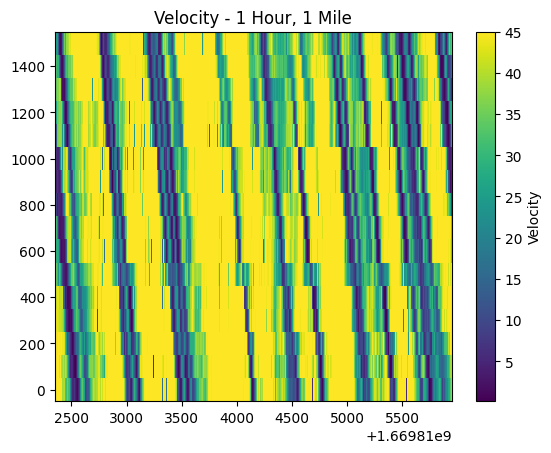

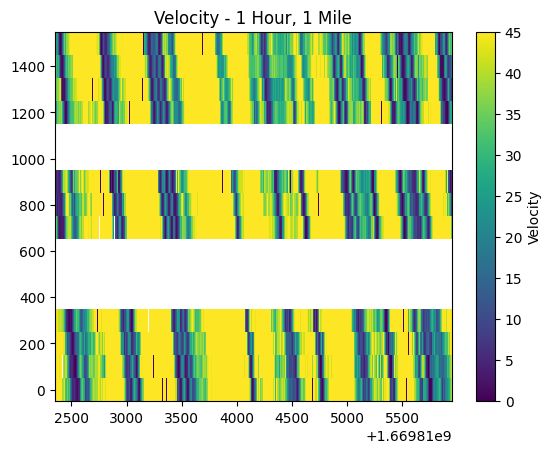

In [114]:
velocity_result_asm_output_display = (velocity_result_asm_output.cpu().detach().numpy()).reshape(3600, 16).T
print(velocity_result_asm_output_display.shape)
print(velocity_result_asm_output_display.min(), velocity_result_asm_output_display.mean(), velocity_result_asm_output_display.max(), velocity_result_asm_output_display.std())
velocity_result_display_stat = velocity_result_display[~numpy.isnan(velocity_result_display)]
print(velocity_result_display_stat.min(), velocity_result_display_stat.mean(), velocity_result_display_stat.max(), velocity_result_display_stat.std())
print(velocity_result_asm_output_display.shape, velocity_result_display.shape)
plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_asm_output_display, cmap='viridis', shading='auto')
plt.title('Velocity - 1 Hour, 1 Mile')
plt.colorbar(label='Velocity')
plt.show()
plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto')
plt.title('Velocity - 1 Hour, 1 Mile')
plt.colorbar(label='Velocity')
plt.show()

In [115]:
#del velocity_result_asm_output
#del density_result_asm_output
gc.collect()
density_result_marked_outages = density_result.copy()
density_result_marked_outages[outage_mask] = numpy.nan
density_result_asm_input = density_result_marked_outages.reshape((1, 1, 3600, 16)).copy()
density_result_asm_input = torch.from_numpy(density_result_asm_input).to("cuda")
"""init_delta: float = 32.0, # meters
init_tau: float = 4.0, # seconds
init_c_cong: float = -5.36, # Meters per second going backwards
init_c_free: float = 20.00 # Meters per second going forwards
init_v_thr: float = 0.1, # vehicles per meter
init_v_delta: float = 0.02 # vehicles per meter"""

asm = AdaptiveSmoothing(3600.0, 1600.0, dx=100.0, dt=1.0, init_delta=15.0, init_tau=1.0, init_c_cong=-7.7, init_c_free=50.0, init_v_thr=0.10, init_v_delta=0.001, high_is_congestion=True).to("cuda")
density_result_asm_output = asm(density_result_asm_input)

(16, 3600)
0.0 0.041187335 0.14 0.019625375
0.00082094624 0.041031748 0.1358699 0.018603155
2793


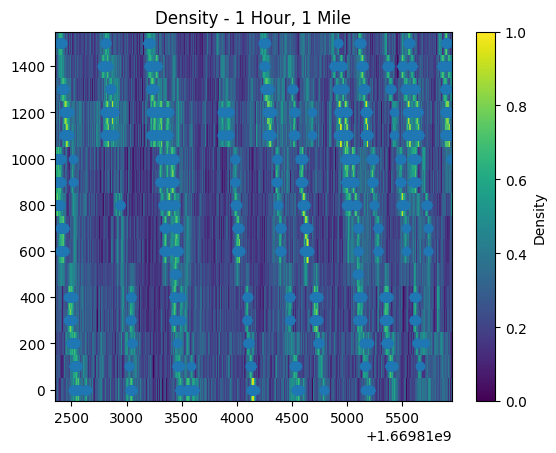

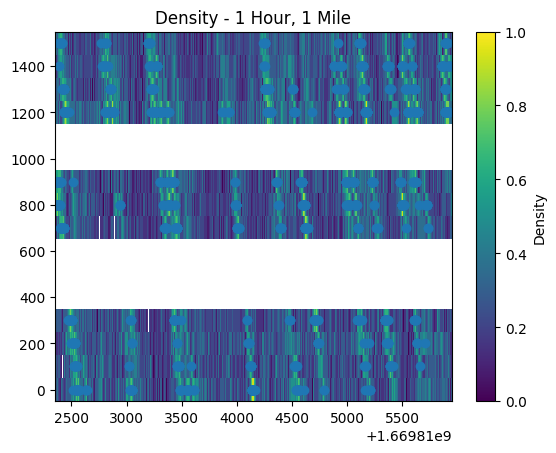

In [116]:
density_result_asm_output_display = (density_result_asm_output.cpu().detach().numpy()).reshape(3600, 16).T
print(density_result_asm_output_display.shape)
density_result_display_stat = density_result_display[~numpy.isnan(density_result_display)]
print(density_result_display_stat.min(), density_result_display_stat.mean(), density_result_display_stat.max(), density_result_display_stat.std())
print(density_result_asm_output_display.min(), density_result_asm_output_display.mean(), density_result_asm_output_display.max(), density_result_asm_output_display.std())
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_asm_output_display, cmap='viridis', shading='auto')
jam_scatters = density_result_asm_output_display > 0.08
jam_time = timestamp_min_display[jam_scatters]
jam_s = s_min_display[jam_scatters]
print(len(jam_time))
plt.scatter(jam_time, jam_s)
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
jam_scatters = density_result_display > 0.08
jam_time = timestamp_min_display[jam_scatters]
jam_s = s_min_display[jam_scatters]
plt.scatter(jam_time, jam_s)
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

In [117]:
def objective(trial):
    #init_delta = trial.suggest_float('init_delta', 1.0, 20.0)
    #init_tau = trial.suggest_float('init_tau', 1.0, 5.0)
    init_c_cong = -7.7
    init_c_free = 50.0
    init_delta = 15.0
    init_tau = 1.0
    #init_delta = trial.suggest_float('init_delta', 1.0, 20.0)
    #init_tau = trial.suggest_float('init_tau', 0.1, 15.0)
    v_thr = trial.suggest_float('v_thr', 10.0, 30.0)
    v_delta = trial.suggest_float('v_delta', 0.5, 10.0)
    #v_thr = 15.00048812939796
    #v_delta = 2.85162298360557
    velocity_result_asm_input = velocity_result_marked_outages.reshape((1, 1, 3600, 16)).copy()
    velocity_result_asm_input[velocity_result_asm_input == 0] = numpy.nan
    velocity_result_asm_input = numpy.clip(velocity_result_asm_input, 0, 45.0)
    rng = numpy.random.default_rng(seed=42)
    noise = rng.normal(loc=0.0, scale=5.0, size=velocity_result_asm_input.shape)
    velocity_result_asm_input_noised = velocity_result_asm_input + noise
    velocity_result_asm_input_noised = numpy.clip(velocity_result_asm_input_noised, 0, 45.0)
    
    velocity_result_asm_input_noised = torch.from_numpy(velocity_result_asm_input_noised).to("cuda").to(torch.float32)
    """init_delta: float = 32.0, # meters
    init_tau: float = 4.0, # seconds
    init_c_cong: float = -5.36, # Meters per second going backwards
    init_c_free: float = 20.00 # Meters per second going forwards
    init_v_thr: float = 17.00, # Meters per second
    init_v_delta: float = 4.5 # Meters per second"""

    #asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=20.0, init_tau=4.0, init_c_cong=-4.435442333413168, init_c_free=31.835619183232694, init_v_thr=10.55926695516419, init_v_delta=1.1422346804487675).to("cuda")
    asm = AdaptiveSmoothing(3600.0, 1600.0, dx=100.0, dt=1.0, init_delta=init_delta, init_tau=init_tau, init_c_cong=init_c_cong, init_c_free=init_c_free, init_v_thr=v_thr, init_v_delta=v_delta).to("cuda")
    velocity_result_asm_output = asm(velocity_result_asm_input_noised)
    velocity_result_asm_output = velocity_result_asm_output.cpu().detach().numpy().reshape(-1)[~outage_mask]
    velocity_base_stat = velocity_result_marked_outages[~outage_mask]
    mae = (abs((velocity_result_asm_output - velocity_base_stat)) / (3600.0 * 16.0)).sum() 
    std_dev_deviation = abs(velocity_base_stat.std() - velocity_result_asm_output.std())
    print(mae, std_dev_deviation)
    return mae + std_dev_deviation
    

study = optuna.create_study()
study.optimize(objective, n_trials=1000)

study.best_params

[I 2026-03-27 13:33:23,138] A new study created in memory with name: no-name-b259b337-9377-4430-8e44-8025f1e8fe86
[I 2026-03-27 13:33:23,200] Trial 0 finished with value: 2.562911033630371 and parameters: {'v_thr': 28.06475037447076, 'v_delta': 3.2230635710673794}. Best is trial 0 with value: 2.562911033630371.
[I 2026-03-27 13:33:23,260] Trial 1 finished with value: 2.563275098800659 and parameters: {'v_thr': 18.996176074150643, 'v_delta': 9.88155315118619}. Best is trial 0 with value: 2.562911033630371.
[I 2026-03-27 13:33:23,320] Trial 2 finished with value: 2.5633511543273926 and parameters: {'v_thr': 18.012340697979035, 'v_delta': 9.884774220795062}. Best is trial 0 with value: 2.562911033630371.
[I 2026-03-27 13:33:23,380] Trial 3 finished with value: 2.5633010864257812 and parameters: {'v_thr': 18.60126227593664, 'v_delta': 9.838812695177282}. Best is trial 0 with value: 2.562911033630371.


1.5859871 0.97692394
1.5861042 0.97717094
1.5861193 0.977232
1.58611 0.977191


[I 2026-03-27 13:33:23,438] Trial 4 finished with value: 2.5631563663482666 and parameters: {'v_thr': 19.76289102329838, 'v_delta': 8.819451704253307}. Best is trial 0 with value: 2.562911033630371.
[I 2026-03-27 13:33:23,497] Trial 5 finished with value: 2.562974691390991 and parameters: {'v_thr': 16.85378626254843, 'v_delta': 3.1179986473586063}. Best is trial 0 with value: 2.562911033630371.
[I 2026-03-27 13:33:23,556] Trial 6 finished with value: 2.5628886222839355 and parameters: {'v_thr': 20.567912036214608, 'v_delta': 4.0055294929304175}. Best is trial 6 with value: 2.5628886222839355.
[I 2026-03-27 13:33:23,614] Trial 7 finished with value: 2.5632150173187256 and parameters: {'v_thr': 14.000335064484604, 'v_delta': 3.353909561220363}. Best is trial 6 with value: 2.5628886222839355.


1.5860884 0.97706795
1.5861013 0.9768734
1.5860552 0.97683334
1.5861614 0.97705364


[I 2026-03-27 13:33:23,672] Trial 8 finished with value: 2.563260316848755 and parameters: {'v_thr': 12.814742143449212, 'v_delta': 1.6539895138643952}. Best is trial 6 with value: 2.5628886222839355.
[I 2026-03-27 13:33:23,730] Trial 9 finished with value: 2.5629806518554688 and parameters: {'v_thr': 24.938890290592944, 'v_delta': 9.653802736297626}. Best is trial 6 with value: 2.5628886222839355.
[I 2026-03-27 13:33:23,790] Trial 10 finished with value: 2.5629467964172363 and parameters: {'v_thr': 22.956818811569605, 'v_delta': 6.977621822697537}. Best is trial 6 with value: 2.5628886222839355.
[I 2026-03-27 13:33:23,849] Trial 11 finished with value: 2.5629029273986816 and parameters: {'v_thr': 29.787201341485112, 'v_delta': 4.824247620184115}. Best is trial 6 with value: 2.5628886222839355.


...

[I 2026-03-27 13:34:23,746] Trial 992 finished with value: 2.562859058380127 and parameters: {'v_thr': 18.316659519902124, 'v_delta': 0.6936835267589809}. Best is trial 241 with value: 2.562835693359375.
[I 2026-03-27 13:34:23,809] Trial 993 finished with value: 2.562840461730957 and parameters: {'v_thr': 19.953189315978623, 'v_delta': 1.0841524423775293}. Best is trial 241 with value: 2.562835693359375.
[I 2026-03-27 13:34:23,872] Trial 994 finished with value: 2.562847137451172 and parameters: {'v_thr': 22.5151129265391, 'v_delta': 1.5986038958590978}. Best is trial 241 with value: 2.562835693359375.
[I 2026-03-27 13:34:23,934] Trial 995 finished with value: 2.5628366470336914 and parameters: {'v_thr': 21.314408451989607, 'v_delta': 0.5038267411832911}. Best is trial 241 with value: 2.562835693359375.


1.5860678 0.9767914
1.586053 0.97678757
1.5860348 0.97681236
1.5860462 0.9767904


[I 2026-03-27 13:34:23,997] Trial 996 finished with value: 2.5628390312194824 and parameters: {'v_thr': 20.910695552813607, 'v_delta': 0.8170606109874975}. Best is trial 241 with value: 2.562835693359375.
[I 2026-03-27 13:34:24,059] Trial 997 finished with value: 2.5628409385681152 and parameters: {'v_thr': 22.040333034332605, 'v_delta': 0.6455442669611965}. Best is trial 241 with value: 2.562835693359375.
[I 2026-03-27 13:34:24,121] Trial 998 finished with value: 2.562836170196533 and parameters: {'v_thr': 21.392113249707055, 'v_delta': 0.5000309839009869}. Best is trial 241 with value: 2.562835693359375.
[I 2026-03-27 13:34:24,183] Trial 999 finished with value: 2.562838077545166 and parameters: {'v_thr': 20.459485479607363, 'v_delta': 0.9418130515917821}. Best is trial 241 with value: 2.562835693359375.


1.5860486 0.9767904
1.5860411 0.97679996
1.5860457 0.9767904
1.5860506 0.97678757


{'v_thr': 21.179563670125958, 'v_delta': 0.5081703252323667}

In [118]:
study.best_params

{'v_thr': 21.179563670125958, 'v_delta': 0.5081703252323667}

In [119]:
def objective(trial):
    #init_delta = trial.suggest_float('init_delta', 1.0, 20.0)
    #init_tau = trial.suggest_float('init_tau', 1.0, 5.0)
    #init_delta = 20.0
    #init_tau = 0.5
    init_c_cong = trial.suggest_float('init_c_cong', -8.0, -4.0)
    init_c_free = trial.suggest_float('init_c_free', 30.0, 60.0)
    #init_c_cong = -6.2
    #init_c_free = 42.0
    init_delta = 15.0
    init_tau = 1.0
    #init_tau = 4.0
    #init_delta = trial.suggest_float('init_delta', 1.0, 250.0)
    #init_tau = trial.suggest_float('init_tau', 1.0, 30.0)
    #init_delta = 1.0903570129365505
    #init_tau = 0.1004015788506238
    v_thr = trial.suggest_float('v_thr', 0.04, 0.10)
    v_delta = trial.suggest_float('v_delta', 0.001, 0.10)
    #v_thr = 15.00048812939796
    #v_delta = 2.85162298360557
    density_result_asm_input = density_result_marked_outages.reshape((1, 1, 3600, 16))
    density_result_asm_input = numpy.clip(density_result_asm_input, 0, 0.2)
    rng = numpy.random.default_rng(seed=42)
    noise = rng.normal(loc=0.0, scale=0.025, size=density_result_asm_input.shape)
    density_result_asm_input_noised = density_result_asm_input + noise
    density_result_asm_input_noised = numpy.clip(density_result_asm_input_noised, 0, 0.2)
    
    density_result_asm_input_noised = torch.from_numpy(density_result_asm_input_noised).to("cuda").to(torch.float32)
    """init_delta: float = 32.0, # meters
    init_tau: float = 4.0, # seconds
    init_c_cong: float = -5.36, # Meters per second going backwards
    init_c_free: float = 20.00 # Meters per second going forwards
    init_v_thr: float = 17.00, # Meters per second
    init_v_delta: float = 4.5 # Meters per second"""
    asm = AdaptiveSmoothing(3600.0, 1600.0, dx=100.0, dt=1.0, init_delta=init_delta, init_tau=init_tau, init_c_cong=init_c_cong, init_c_free=init_c_free, init_v_thr=v_thr, init_v_delta=v_delta, high_is_congestion=True).to("cuda")
    density_result_asm_output = asm(density_result_asm_input_noised)
    density_result_asm_output = density_result_asm_output.cpu().detach().numpy().reshape(-1)[~outage_mask]
    density_base_stat = density_result_marked_outages[~outage_mask]
    mae = (abs((density_result_asm_output - density_base_stat)) / (3600.0 * 16.0)).sum() 
    std_dev_deviation = abs(density_base_stat.std() - density_result_asm_output.std())
    print(mae, std_dev_deviation)
    return mae + std_dev_deviation
    

study = optuna.create_study()
study.optimize(objective, n_trials=1000)

study.best_params

[I 2026-03-27 13:34:24,381] A new study created in memory with name: no-name-5d246c80-6ff2-4ae8-ab57-5fd4e9feebc4
[I 2026-03-27 13:34:24,441] Trial 0 finished with value: 0.00918634794652462 and parameters: {'init_c_cong': -5.859931931010134, 'init_c_free': 53.43917177506165, 'v_thr': 0.07671242506294204, 'v_delta': 0.0561893610766067}. Best is trial 0 with value: 0.00918634794652462.
[I 2026-03-27 13:34:24,499] Trial 1 finished with value: 0.009186559356749058 and parameters: {'init_c_cong': -6.962401281954966, 'init_c_free': 30.96743199624131, 'v_thr': 0.09031841216602347, 'v_delta': 0.09219034315712661}. Best is trial 0 with value: 0.00918634794652462.
[I 2026-03-27 13:34:24,558] Trial 2 finished with value: 0.009188049472868443 and parameters: {'init_c_cong': -6.22874839271394, 'init_c_free': 39.45436148270079, 'v_thr': 0.05766680683322112, 'v_delta': 0.045173369603226876}. Best is trial 0 with value: 0.00918634794652462.
[I 2026-03-27 13:34:24,615] Trial 3 finished with value: 0.0

0.0071978234 0.0019885246
0.0071980646 0.0019884948
0.0071980236 0.0019900259
0.007197625 0.001987407


[I 2026-03-27 13:34:24,674] Trial 4 finished with value: 0.009188278578221798 and parameters: {'init_c_cong': -4.783888313987136, 'init_c_free': 56.73539837770798, 'v_thr': 0.04608071622492048, 'v_delta': 0.047913530655547876}. Best is trial 3 with value: 0.009185031987726688.
[I 2026-03-27 13:34:24,732] Trial 5 finished with value: 0.009186276234686375 and parameters: {'init_c_cong': -4.137582787527413, 'init_c_free': 47.508077794403505, 'v_thr': 0.07133034423176374, 'v_delta': 0.09867351404889334}. Best is trial 3 with value: 0.009185031987726688.
[I 2026-03-27 13:34:24,791] Trial 6 finished with value: 0.00918864831328392 and parameters: {'init_c_cong': -4.210912233505824, 'init_c_free': 46.9303925160244, 'v_thr': 0.05330847357458039, 'v_delta': 0.01271079735081421}. Best is trial 3 with value: 0.009185031987726688.
[I 2026-03-27 13:34:24,850] Trial 7 finished with value: 0.009190160781145096 and parameters: {'init_c_cong': -5.752951428088377, 'init_c_free': 43.87430275348166, 'v_th

0.007197964 0.0019903146
0.007197841 0.0019884352
0.007197717 0.001990931
0.0071984376 0.0019917227


[I 2026-03-27 13:34:24,908] Trial 8 finished with value: 0.009188726544380188 and parameters: {'init_c_cong': -6.3397231041724575, 'init_c_free': 44.11070340548388, 'v_thr': 0.04027386835452154, 'v_delta': 0.041387572089672926}. Best is trial 3 with value: 0.009185031987726688.
[I 2026-03-27 13:34:24,967] Trial 9 finished with value: 0.009188723750412464 and parameters: {'init_c_cong': -5.4275464808017855, 'init_c_free': 44.055949306128994, 'v_thr': 0.057640568164212466, 'v_delta': 0.06790520569343204}. Best is trial 3 with value: 0.009185031987726688.
[I 2026-03-27 13:34:25,028] Trial 10 finished with value: 0.009186804294586182 and parameters: {'init_c_cong': -7.91511660992691, 'init_c_free': 59.834116342322034, 'v_thr': 0.0984227687642063, 'v_delta': 0.07897672113428493}. Best is trial 3 with value: 0.009185031987726688.
[I 2026-03-27 13:34:25,089] Trial 11 finished with value: 0.009185667149722576 and parameters: {'init_c_cong': -4.083941230952895, 'init_c_free': 50.42115629564234,

...

[I 2026-03-27 13:35:27,862] Trial 992 finished with value: 0.009184039197862148 and parameters: {'init_c_cong': -7.658649157350539, 'init_c_free': 49.62828129610637, 'v_thr': 0.09555000839794853, 'v_delta': 0.012267467722421137}. Best is trial 918 with value: 0.009183249436318874.
[I 2026-03-27 13:35:27,929] Trial 993 finished with value: 0.009184129536151886 and parameters: {'init_c_cong': -7.5725022754217335, 'init_c_free': 50.47221581327185, 'v_thr': 0.09718605946837938, 'v_delta': 0.009822711777798837}. Best is trial 918 with value: 0.009183249436318874.
[I 2026-03-27 13:35:27,995] Trial 994 finished with value: 0.009183933027088642 and parameters: {'init_c_cong': -7.757093066397136, 'init_c_free': 49.15581380022102, 'v_thr': 0.09879522856964665, 'v_delta': 0.0069651014104282205}. Best is trial 918 with value: 0.009183249436318874.
[I 2026-03-27 13:35:28,061] Trial 995 finished with value: 0.009185444563627243 and parameters: {'init_c_cong': -7.6277238433673435, 'init_c_free': 48.2

0.0071976455 0.0019863937
0.0071976855 0.001986444
0.0071976976 0.0019862354
0.007197678 0.0019877665


[I 2026-03-27 13:35:28,128] Trial 996 finished with value: 0.009184388443827629 and parameters: {'init_c_cong': -7.500254703943035, 'init_c_free': 51.063961595048916, 'v_thr': 0.09887367339596462, 'v_delta': 0.014369152795994496}. Best is trial 918 with value: 0.009183249436318874.
[I 2026-03-27 13:35:28,195] Trial 997 finished with value: 0.009183555841445923 and parameters: {'init_c_cong': -7.709628206992772, 'init_c_free': 49.88103301078573, 'v_thr': 0.09771109714959537, 'v_delta': 0.008249001532752665}. Best is trial 918 with value: 0.009183249436318874.
[I 2026-03-27 13:35:28,262] Trial 998 finished with value: 0.009184797294437885 and parameters: {'init_c_cong': -7.855878277468825, 'init_c_free': 52.286935638592944, 'v_thr': 0.09892793506514777, 'v_delta': 0.010794835033200518}. Best is trial 918 with value: 0.009183249436318874.
[I 2026-03-27 13:35:28,328] Trial 999 finished with value: 0.009183982387185097 and parameters: {'init_c_cong': -7.791671550791164, 'init_c_free': 50.41

0.0071977656 0.0019866228
0.007197577 0.0019859783
0.007197934 0.001986863
0.007197671 0.0019863117


{'init_c_cong': -7.714445177876905,
 'init_c_free': 49.963597666450454,
 'v_thr': 0.09999173099040831,
 'v_delta': 0.009225200568562852}

In [120]:
study.best_params

{'init_c_cong': -7.714445177876905,
 'init_c_free': 49.963597666450454,
 'v_thr': 0.09999173099040831,
 'v_delta': 0.009225200568562852}